# Cap. 03 — Introducción a los Algoritmos Cuánticos
## Listing 3-1: Mediciones tras una transformada Hadamard en un qubit (Cirq)

**Referencia:** Pattanayak, *Quantum Machine Learning with Python*, Capítulo 3, Listing 3-1.

Un qubit inicializado en |0⟩ pasa por una compuerta Hadamard, quedando en superposición igual:

$$|+\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$$

Al medir 100 copias del estado esperamos ~50 resultados en cada base.

### Definición del circuito

In [1]:
import cirq

qubit = cirq.GridQubit(0, 0)

circuit = cirq.Circuit([
    cirq.H(qubit),
    cirq.measure(qubit, key='m'),
])

print(circuit)

(0, 0): ───H───M('m')───


### Visualización del circuito

Cirq no incluye un graficador matplotlib nativo (a diferencia de Qiskit). Se renderiza el diagrama de texto dentro de una figura.

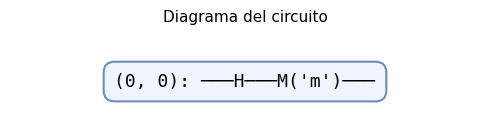

In [2]:
import matplotlib.pyplot as plt

diagrama = circuit.to_text_diagram()

fig, ax = plt.subplots(figsize=(5, 1.5))
ax.text(
    0.5, 0.5, diagrama,
    fontfamily='monospace', fontsize=13,
    ha='center', va='center',
    bbox=dict(boxstyle='round,pad=0.6', facecolor='#f0f4ff', edgecolor='#6c8ebf', linewidth=1.5),
)
ax.axis('off')
ax.set_title('Diagrama del circuito', fontsize=11, pad=8)
plt.tight_layout()
plt.show()

### Simulación

In [3]:
sim = cirq.Simulator()
output = sim.run(circuit, repetitions=100)

print("Salida de medición:")
print(output)
print()
print("Histograma:")
print(output.histogram(key='m'))

Salida de medición:
m=0001000010000011110101000010010100010011110000011111100101010011011111001000101001111010111101010110

Histograma:
Counter({0: 52, 1: 48})


### Histograma de mediciones

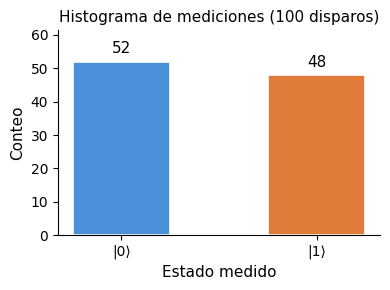

In [6]:
from qml_santanu.common.plot_utils import plot_counts

_ = plot_counts(output.histogram(key='m'), shots=100)